In [1]:
import pandas as pd
from google.colab import files
from textblob import TextBlob
import matplotlib.pyplot as plt

uploaded = files.upload()
glassdoor_df = pd.read_csv('glassdoor_cleaned_text.csv')

Saving glassdoor_cleaned_text.csv to glassdoor_cleaned_text.csv


In [2]:
print(glassdoor_df.columns.tolist())

['review_id', 'rating_date', 'employee_length', 'employee_status', 'employee_type', 'flag_covid', 'flag_featured', 'flags_business_outlook', 'flags_ceo_approval', 'flags_recommend_frend', 'rating_culture_values', 'rating_diversity_inclusion', 'rating_overall', 'rating_work_life', 'summary', 'employee_location', 'employee_job_title', 'advice_to_management', 'review_pros', 'review_cons', 'rating_compensation_benefits', 'rating_senior_leadership', 'rating_career_opportunities', 'summary_cleaned', 'advice_to_management_cleaned', 'review_pros_cleaned', 'review_cons_cleaned']


In [3]:
glassdoor_df['sentiment_polarity'] = glassdoor_df['summary_cleaned'].apply(lambda x: TextBlob(x).sentiment.polarity)
glassdoor_df['sentiment_subjectivity'] = glassdoor_df['summary_cleaned'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

print(glassdoor_df[['summary_cleaned', 'sentiment_polarity', 'sentiment_subjectivity']].head(10))

             summary_cleaned  sentiment_polarity  sentiment_subjectivity
0                     amazon            0.000000                0.000000
1                       good            0.700000                0.600000
2            good experience            0.700000                0.600000
3                       dhdh            0.000000                0.000000
4              good pay rate            0.700000                0.600000
5  worst american sweat shop           -0.500000                0.500000
6                  warehouse            0.000000                0.000000
7                 less ideal            0.366667                0.533333
8                     amazon            0.000000                0.000000
9     keep going keep trying            0.000000                0.000000


In [4]:
def label_sentiment(score):
    if score > 0.1:
        return 'positive'
    elif score < -0.1:
        return 'negative'
    else:
        return 'neutral'

glassdoor_df['sentiment_label'] = glassdoor_df['sentiment_polarity'].apply(label_sentiment)

print(glassdoor_df[['summary_cleaned', 'sentiment_polarity', 'sentiment_label']].head(10))

             summary_cleaned  sentiment_polarity sentiment_label
0                     amazon            0.000000         neutral
1                       good            0.700000        positive
2            good experience            0.700000        positive
3                       dhdh            0.000000         neutral
4              good pay rate            0.700000        positive
5  worst american sweat shop           -0.500000        negative
6                  warehouse            0.000000         neutral
7                 less ideal            0.366667        positive
8                     amazon            0.000000         neutral
9     keep going keep trying            0.000000         neutral


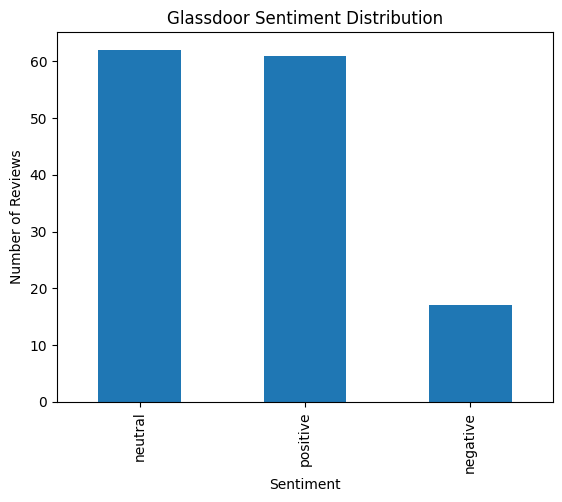

In [5]:
glassdoor_df['sentiment_label'].value_counts().plot(kind='bar', title="Glassdoor Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

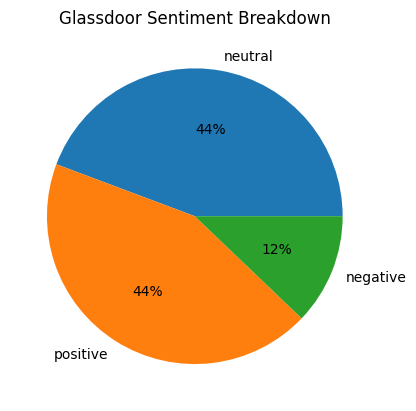

In [6]:
glassdoor_df['sentiment_label'].value_counts().plot(
    kind='pie',
    autopct='%1.0f%%',
    title="Glassdoor Sentiment Breakdown"
)
plt.ylabel('')
plt.show()

In [7]:
glassdoor_df.to_csv('glassdoor_sentiment.csv', index=False)